In [1]:
import tensorflow as tf
(x_train,y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [3]:
x_train.shape

(60000, 28, 28)

In [4]:
x_test.shape

(10000, 28, 28)

In [5]:
# Add channel dimension (for CNN input) - So, CNN can learn patterns (edges, shapes)
# Grayscale image --> no of channel=1
# Colour image --> no of channels=3
# Since MNIST digits are grayscale images, they have only one channel representing pixel intensity.

x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)    # x_train.shape[0] = 60000 --> reshaping into (60000,28,28,1)

# Same reshape for test data
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# Define input size for model
input_shape = (28, 28, 1)

In [6]:
x_train.shape

(60000, 28, 28, 1)

In [7]:
# Convert data type to float (for calculations)
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [8]:
# Normalize pixel values (0–255 → 0–1)
# Pixel values = 0 to 255 --> If we use big numbers: Training becomes slow, Model unstable
# So we convert: 255 → 1 , 128 → 0.5
# Dividing by 255 
# a += 5 --> a = a+5

x_train /= 255
x_test /= 255

In [9]:
# Model building
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D

model = Sequential() # Create empty model
model.add(Conv2D(28, kernel_size=(3,3), input_shape=input_shape))  # Apply 28 filters to detect patterns
model.add(MaxPooling2D(pool_size=(2,2)))    # Reduce image size (keep important info)
model.add(Flatten())   # Convert 2D image → 1D vector
model.add(Dense(128, activation=tf.nn.relu))   # Hidden layer (learn patterns)
model.add(Dropout(0.2))   # Drop 20% neurons to avoid overfitting
model.add(Dense(10, activation=tf.nn.softmax))   # Output layer (10 classes: digits 0–9)

C:\Users\Default.DESKTOP-73FCCDO\Documents\Installations\envs\aiml\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Compile + Train
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])  # Configure learning method
model.fit(x=x_train, y=y_train, epochs=10)  # Train model for 10 rounds

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9396 - loss: 0.2038
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9760 - loss: 0.0779
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9833 - loss: 0.0548
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9865 - loss: 0.0419
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9887 - loss: 0.0329
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9910 - loss: 0.0270
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9910 - loss: 0.0249
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9925 - loss: 0.0210
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9933 - loss: 0.0193
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9940 - loss: 0.0177


<h5 style="color:darkblue;"> 
• Adam Optimizer - It's like a smart weight updater --> It will think, How should I adjust myself to improve?<br><br>
• Loss: sparse_categorical_crossentropy - It measures error between, actual label and predicted probability --> It will think, How wrong am I?<br>
- Also the label format of, <br>
    -- categorical_crossentropy -- > one-hot encoded<br>
    -- sparse_categorical_crossentropy --> integer (so, no need argmax on y_test)<br><br>
• Accuracy - It's the % of correct predictions --> It will think, How often am I right?<br>
        
</h5>

In [12]:
# Test model performance
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9837 - loss: 0.0656


[0.06558609753847122, 0.9836999773979187]

In [17]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predict all test data
y_pred = model.predict(x_test)

# Convert probabilities → labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
print("Confusion Matrix:\n", cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Confusion Matrix:
 [[ 973    0    1    1    0    0    4    0    1    0]
 [   0 1127    3    2    0    0    1    1    1    0]
 [   1    3 1013    1    1    0    2    8    3    0]
 [   0    0    4  997    0    4    0    2    1    2]
 [   0    0    1    0  963    0    4    0    3   11]
 [   2    0    1    6    1  874    4    0    3    1]
 [   3    3    1    1    1    2  944    0    3    0]
 [   0    3   12    1    1    0    0 1004    3    4]
 [   3    0    1    4    2    2    0    2  959    1]
 [   1    2    0    4    6    2    1    3    7  983]]


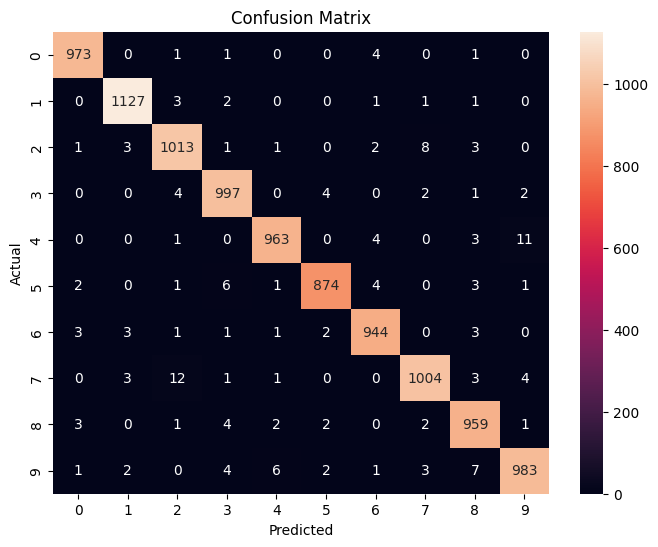

In [18]:
# Plot Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.99      0.98      1010
           4       0.99      0.98      0.98       982
           5       0.99      0.98      0.98       892
           6       0.98      0.99      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.97      0.98      0.98       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step
6


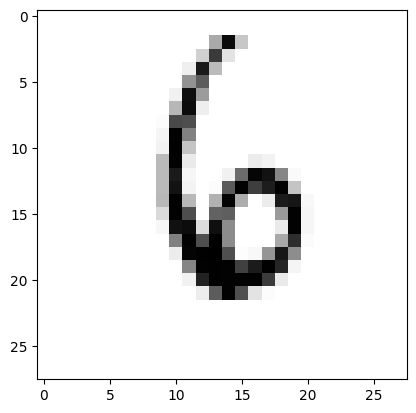

In [14]:
# Testing and display results
import matplotlib.pyplot as plt

image_index = 6900  # Select one image
plt.imshow(x_test[image_index].reshape(28, 28), cmap = 'Greys')   # Show image
predict = x_test[image_index].reshape(28, 28)   # Prepare image
pred = model.predict(x_test[image_index].reshape(1, 28, 28, 1))   # Predict digit
print(pred.argmax())         # Print predicted number       